<a href="https://colab.research.google.com/github/willow788/one-model-a-week-keeps-the-fomo-away/blob/main/cartooonfied.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install opencv-python

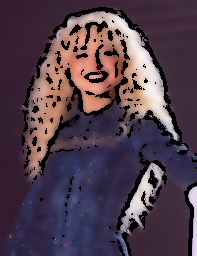

In [9]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread('/content/screenshot.png')

#if there is no image return not found
if image is None:
    print("Image not found")


#convert to greyscale
image_grayed = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#median blur
image_grayed_and_blurred = cv2.medianBlur(image_grayed, 5)

#edges
edges = cv2.adaptiveThreshold(image_grayed_and_blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                              cv2.THRESH_BINARY, 9, 9)

#smooth color
color = cv2.bilateralFilter(image, 9, 250, 250)

#combine
cartoon = cv2.bitwise_and(color, color, mask=edges)

#save
cv2_imshow(cartoon)
cv2.imwrite("cartoonified.jpg", cartoon)
cv2.waitKey(0)
cv2.destroyAllWindows()